In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [48]:

def analyse_scalers(data, row_name="Data"):
    reusults = {}
    # Verteilungsanalyse
    print(f"{'#'*10} Analyse: {row_name.upper()} {'#'*10}")


    # 3. SKALIERUNGSVERGLEICH
    print("\n3. SKALIERUNGSVERGLEICH")
    print("-" * 50)

    
    scaling_results = {}

    for name, scaler in scalers.items():
        if callable(scaler) and name in ['Log-Transform', 'Square-Root', 'Original']:
            transformed = scaler(data)
        else:
            transformed = scaler.fit_transform(data.values.reshape(-1, 1)).flatten()
        
        scaling_results[name] = {
            'mean': np.mean(transformed),
            'std': np.std(transformed),
            'min': np.min(transformed),
            'max': np.max(transformed),
            'range': np.max(transformed) - np.min(transformed),
            'skewness': stats.skew(transformed),
            'kurtosis' : stats.kurtosis(transformed)
        }


    # Ergebnisse anzeigen
    print("Skalierungsvergleich:")
    for name, stats_dict in scaling_results.items():
        print(f"\n{name}:")
        print(f"  Mean: {stats_dict['mean']:.4f}")
        print(f"  Std:  {stats_dict['std']:.4f}")
        print(f"  Range: [{stats_dict['min']:.4f}, {stats_dict['max']:.4f}]")
        print(f"  Spannweite: {stats_dict['range']:.4f}")
        print(f"  Schiefe: {stats_dict['skewness']:.4f}")
        print(f"  Wölbung: {stats_dict['kurtosis']:.4f}")
    print("\n" + "#" * 50 + "\n")

# Analyse der Regressionswerte

In [49]:
#laden der Daten aus der fabwave_targets.csv aus der primary_to_feature pipeline
csv_path = '/clear-shape/data/4_feature/fabwave_targets.csv'  # z.B. "data/bauteile.csv"
df = pd.read_csv(csv_path)

# columns to analyze
numeric_cols = ['volume', 'faces', 'edges', 'vertices']

#setup possible scalers
scalers = {
    'Original': lambda x: x,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'Log-Transform': lambda x: np.log1p(x),
    'Square-Root': lambda x: np.sqrt(x),
}

#get basic statistics
df[numeric_cols].describe()

,volume,faces,edges,vertices
count,2.659000e+03,2659.000000,2659.000000,2659.000000
mean,4.164949e+05,16.107183,42.599097,28.650997
std,2.841826e+06,44.994734,134.302505,89.502959
min,8.656611e-01,1.000000,2.000000,1.000000
25%,1.100156e+03,4.000000,6.000000,4.000000
50%,6.988209e+03,8.000000,19.000000,13.000000
75%,5.093953e+04,16.000000,39.000000,26.000000
max,4.506484e+07,1283.000000,3843.000000,2562.000000


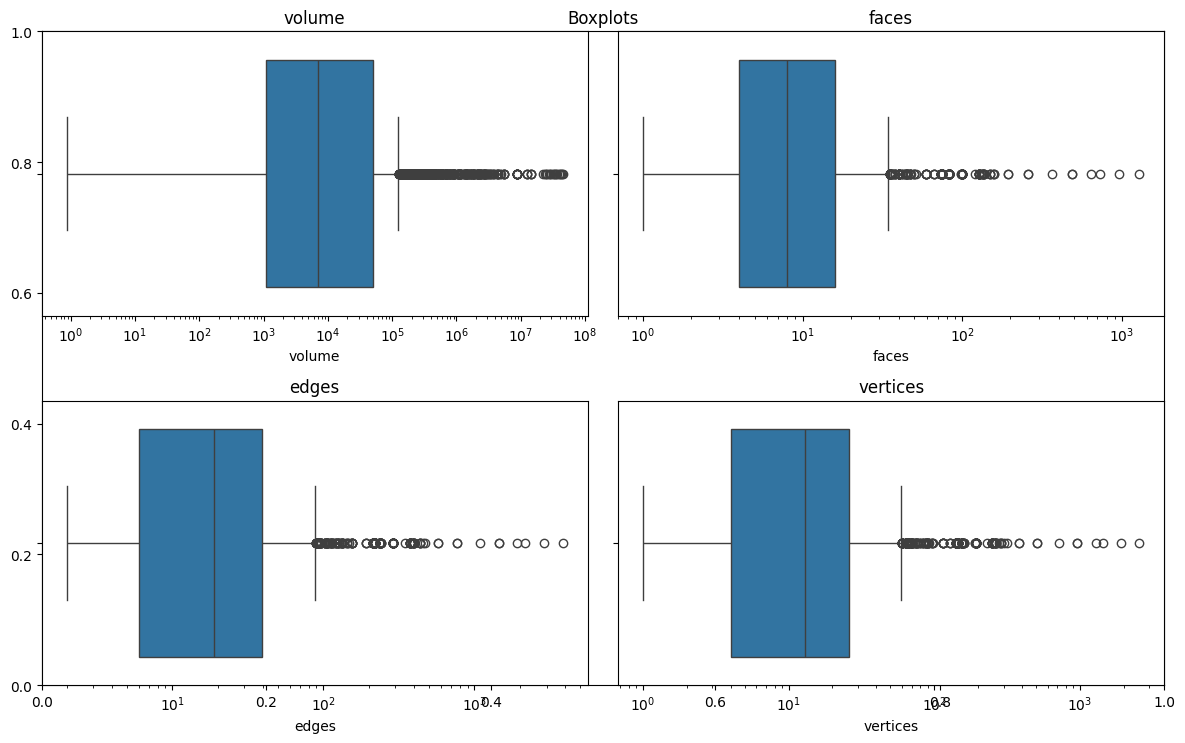

In [50]:
#boxplot to visualize distributions
plt.figure(figsize=(12, 8))
plt.title("Boxplots")
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    #with log scale for better visibility
    sns.boxplot(x=df[col])
    plt.xscale('log')
    plt.title(f'{col}')
plt.tight_layout()
plt.show()

## Volume Analysis

In [51]:
for row in numeric_cols:
    
    analyse_scalers(df[row], row_name=row)


########## Analyse: VOLUME ##########

3. SKALIERUNGSVERGLEICH
--------------------------------------------------
Skalierungsvergleich:

Original:
  Mean: 416494.9083
  Std:  2841291.0796
  Range: [0.8657, 45064835.6058]
  Spannweite: 45064834.7402
  Schiefe: 11.3360
  Wölbung: 140.6612

StandardScaler:
  Mean: 0.0000
  Std:  1.0000
  Range: [-0.1466, 15.7141]
  Spannweite: 15.8607
  Schiefe: 11.3360
  Wölbung: 140.6612

MinMaxScaler:
  Mean: 0.0092
  Std:  0.0630
  Range: [0.0000, 1.0000]
  Spannweite: 1.0000
  Schiefe: 11.3360
  Wölbung: 140.6612

RobustScaler:
  Mean: 8.2165
  Std:  57.0090
  Range: [-0.1402, 904.0613]
  Spannweite: 904.2014
  Schiefe: 11.3360
  Wölbung: 140.6612

Log-Transform:
  Mean: 8.9286
  Std:  2.8894
  Range: [0.6236, 17.6236]
  Spannweite: 17.0000
  Schiefe: 0.0900
  Wölbung: 0.0911

Square-Root:
  Mean: 254.8501
  Std:  592.9134
  Range: [0.9304, 6713.0348]
  Spannweite: 6712.1043
  Schiefe: 6.3872
  Wölbung: 51.6024

######################################

## Analyse Vertices


In [30]:

analyse_scalers(df['vertices'])


Verteilungsmetriken:
  Schiefe (Skewness): 16.1305
  Wölbung (Kurtosis): 363.6063

3. SKALIERUNGSVERGLEICH
--------------------------------------------------
Skalierungsvergleich:

Original:
  Mean: 28.6510
  Std:  89.4861
  Range: [1.0000, 2562.0000]
  Spannweite: 2561.0000
  Schiefe: 16.1305
  Wölbung: 363.6063

StandardScaler:
  Mean: 0.0000
  Std:  1.0000
  Range: [-0.3090, 28.3100]
  Spannweite: 28.6190
  Schiefe: 16.1305
  Wölbung: 363.6063

MinMaxScaler:
  Mean: 0.0108
  Std:  0.0349
  Range: [0.0000, 1.0000]
  Spannweite: 1.0000
  Schiefe: 16.1305
  Wölbung: 363.6063

RobustScaler:
  Mean: 0.7114
  Std:  4.0676
  Range: [-0.5455, 115.8636]
  Spannweite: 116.4091
  Schiefe: 16.1305
  Wölbung: 363.6063

Log-Transform:
  Mean: 2.4424
  Std:  1.2779
  Range: [0.6931, 7.8489]
  Spannweite: 7.1558
  Schiefe: 0.3611
  Wölbung: -0.1024

Square-Root:
  Mean: 4.0304
  Std:  3.5223
  Range: [1.0000, 50.6162]
  Spannweite: 49.6162
  Schiefe: 3.6875
  Wölbung: 27.9097
